<p style="font-family:Bookman Old Style;font-size:27px; text-align:center">Convolution VS. Correlation</p>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">Correlation and convolution are both essential operations in image processing, yet they serve different purposes. Correlation measures the similarity between two signals or between an image and a kernel, assessing how closely they match as the kernel slides over the image without flipping it. It is often used in template matching and feature detection. In contrast, convolution involves combining two functions—specifically, the image and a kernel—where the kernel is flipped before it is applied to the image. This operation is typically employed in filtering tasks such as blurring, sharpening, and edge detection. The main distinctions between them lie in the orientation of the kernel (flipped in convolution, not in correlation) and their applications, with correlation focusing on similarity and convolution on modifying the original image. Understanding these differences is crucial for selecting the appropriate technique for various image processing tasks.</p></div>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">we apply an asymmetric 3 x 3 ripple kernel ([[0,-1,sqrt(2)],[1,0,-1],[-sqrt(2),1,0]]) onto it separately with correlation2d()and convolution2d():</p></div>

<p style="font-family:Bookman Old Style;font-size:27px">Import Libraries</p>

In [6]:
import cv2
import scipy as sc
import numpy as np
import matplotlib.pyplot as plt

<p style="font-family:Bookman Old Style;font-size:27px">Reading image and convert to grayscale</p>

In [7]:
img = cv2.imread('../images-videos/lenna-resized.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

<p style="font-family:Bookman Old Style;font-size:27px">Applying convolution with asymmetric kernel</p>

In [8]:
kernel = np.array([[0, -1, np.sqrt(2)], [1, 0, -1], [-np.sqrt(2), 1, 0]])

convolved_img = np.clip(sc.signal.convolve2d(img_gray, kernel),
                        0, 1)

<p style="font-family:Bookman Old Style;font-size:27px">Displaying convolution result</p>

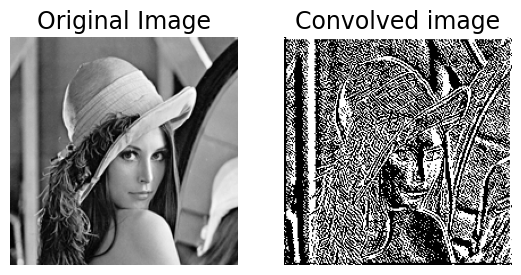

In [9]:
plt.figure(figsize=(10, 5))

plt.subplot(131)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Image', size=17)
plt.axis('off')

plt.subplot(132)
plt.imshow(convolved_img, cmap='gray')
plt.title('Convolved image', size=17)
plt.axis('off')

plt.show()

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">The SciPy signal module's correlated2d() function can be used for correlation.<br>
 Correlation is similar to convolution if the kernel is symmetric.<br>
 But if the kernel is not symmetric, in order to get the same results as
 with convolution2d(), before placing the kernel onto the image, one must flip it upside
down and left-to-right.</p></div>

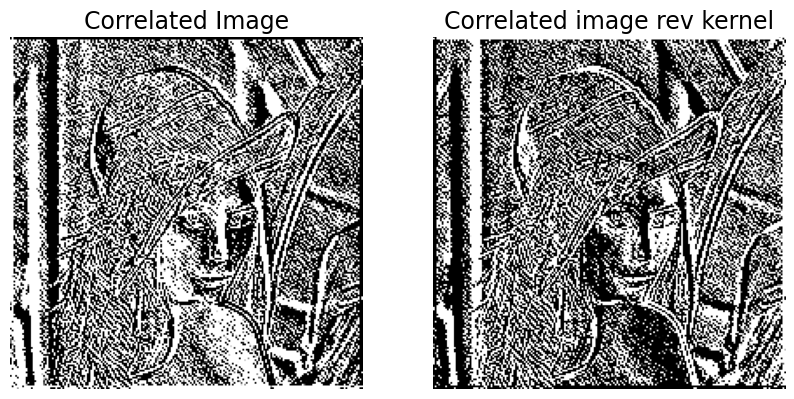

In [10]:
import cv2
import scipy as sc
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('../images-videos/lenna-resized.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

kernel = np.array([[0, -1, np.sqrt(2)], [1, 0, -1], [-np.sqrt(2), 1, 0]])

# convolved_img = np.clip(sc.signal.convolve2d(img_gray, kernel),
#                         0, 1)

correlated_img = np.clip(sc.signal.correlate2d(img_gray, kernel),
                         0, 1)

flipped_kernel = np.fliplr(np.flipud(kernel))
correlated_rev_img = np.clip(sc.signal.correlate2d(img_gray, flipped_kernel),
                             0, 1)

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(correlated_img, cmap='gray')
plt.title('Correlated Image', size=17)
plt.axis('off')

plt.subplot(122)
plt.imshow(correlated_rev_img, cmap='gray')
plt.title('Correlated image rev kernel', size=17)
plt.axis('off')

plt.show()


<p style="font-family:Bookman Old Style;font-size:27px">Difference between convolution and correlation</p>

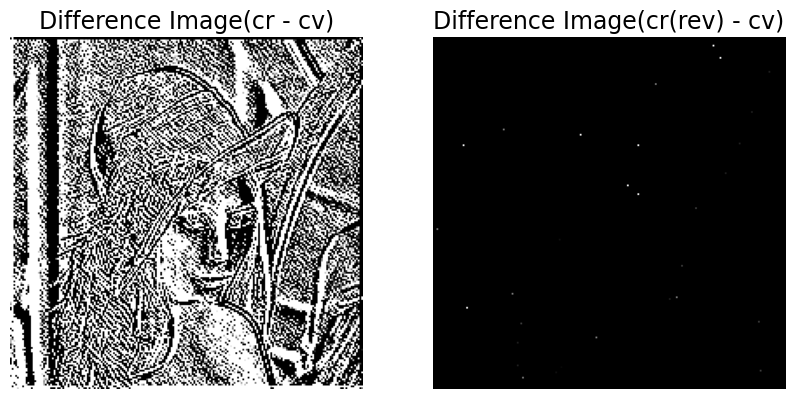

In [11]:
import cv2
import scipy as sc
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('../images-videos/lenna-resized.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

kernel = np.array([[0, -1, np.sqrt(2)], [1, 0, -1], [-np.sqrt(2), 1, 0]])

convolved_img = np.clip(sc.signal.convolve2d(img_gray, kernel),
                        0, 1)

correlated_img = np.clip(sc.signal.correlate2d(img_gray, kernel),
                         0, 1)

flipped_kernel = np.fliplr(np.flipud(kernel))
correlated_rev_img = np.clip(sc.signal.correlate2d(img_gray, flipped_kernel),
                             0, 1)

dif1 = correlated_img - convolved_img

dif2 = np.clip(correlated_rev_img - convolved_img, 0, 255)

plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(dif1, cmap='gray')
plt.title('Difference Image(cr - cv)', size=17)
plt.axis('off')

plt.subplot(122)
plt.imshow(dif2, cmap='gray')
plt.title('Difference Image(cr(rev) - cv)', size=17)
plt.axis('off')

plt.show()
